In [ ]:
import os, time, gzip, shutil, json
import numpy as np
import pandas as pd
import joblib
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Layer, Conv2D, MaxPooling2D, Flatten, Dense,
                                     GlobalAveragePooling2D, Reshape, Multiply, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# ----------------------------------------------------------------------------
# Custom ChannelAttention layer (must be identical to training.ipynb so that
# the saved .keras model can be loaded back successfully).
# ----------------------------------------------------------------------------
class ChannelAttention(Layer):
    """Channel Attention Module — same as used in training."""
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels      = input_shape[-1]
        self.gap      = GlobalAveragePooling2D()
        self.dense1   = Dense(max(1, channels // self.ratio), activation="relu")
        self.dense2   = Dense(channels, activation="sigmoid")
        self.reshape  = Reshape((1, 1, channels))
        super().build(input_shape)

    def call(self, x):
        attn = self.gap(x)
        attn = self.dense1(attn)
        attn = self.dense2(attn)
        attn = self.reshape(attn)
        return Multiply()([x, attn])

    def get_config(self):
        config = super().get_config()
        config.update({"ratio": self.ratio})
        return config

CUSTOM_OBJECTS = {"ChannelAttention": ChannelAttention}


In [ ]:
import random, os
import numpy as np
import tensorflow as tf

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print(f"[INFO] enable_op_determinism: {e}")

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for g in gpus:
        try: tf.config.experimental.set_memory_growth(g, True)
        except RuntimeError: pass
    print(f"GPU detected: {[g.name for g in gpus]}")
else:
    print("Running on CPU.")


TensorFlow version: 2.10.0
GPU detected: ['/physical_device:GPU:0']


In [ ]:
# ============================================================================
# UNIFIED EVALUATION HELPERS  (same definitions across all 4 notebooks)
# ============================================================================

def get_file_size_kb(path):
    """File size in KB, or 0.0 if missing."""
    return os.path.getsize(path) / 1024.0 if os.path.exists(path) else 0.0

def fmt_size(kb):
    if kb < 1024: return f"{kb:.2f} KB"
    return f"{kb/1024:.2f} MB"

def evaluate_pipeline(extractor, svm_clf, scaler, X_test, y_test_int,
                      class_names, label="Model", warmup=True):
    """Runs feature extraction + scaling + SVM prediction.
    Returns a dict containing accuracy, sensitivity, specificity, F1, AUC,
    confusion matrix, feature-extraction time, inference time."""

    # warm-up so first-call graph compilation does not pollute timing
    if warmup:
        try:
            _ = extractor.predict(X_test[:2], verbose=0)
        except Exception:
            pass

    # ---- timing: feature extraction ----
    t0 = time.perf_counter()
    X_test_feat = extractor.predict(X_test, verbose=0)
    feat_time = time.perf_counter() - t0

    # ---- timing: scaling + SVM inference ----
    t0 = time.perf_counter()
    X_test_scaled = scaler.transform(X_test_feat)
    y_pred        = svm_clf.predict(X_test_scaled)
    y_pred_proba  = svm_clf.predict_proba(X_test_scaled)
    inf_time      = time.perf_counter() - t0

    n_classes = len(class_names)
    cm        = confusion_matrix(y_test_int, y_pred, labels=list(range(n_classes)))

    sens, spec, prec, f1s = [], [], [], []
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        s  = TP/(TP+FN) if (TP+FN)>0 else 0.0
        sp = TN/(TN+FP) if (TN+FP)>0 else 0.0
        p  = TP/(TP+FP) if (TP+FP)>0 else 0.0
        f  = 2*p*s/(p+s) if (p+s)>0 else 0.0
        sens.append(s); spec.append(sp); prec.append(p); f1s.append(f)

    y_test_bin   = label_binarize(y_test_int, classes=list(range(n_classes)))
    auc_per_cls  = roc_auc_score(y_test_bin, y_pred_proba, average=None , multi_class="ovr")
    auc_macro    = roc_auc_score(y_test_bin, y_pred_proba, average="macro", multi_class="ovr")
    auc_micro    = roc_auc_score(y_test_bin, y_pred_proba, average="micro", multi_class="ovr")
    accuracy     = accuracy_score(y_test_int, y_pred)

    return {
        "label"        : label,
        "accuracy"     : accuracy,
        "sensitivity"  : list(sens),
        "specificity"  : list(spec),
        "precision"    : list(prec),
        "f1"           : list(f1s),
        "auc_per_class": list(auc_per_cls),
        "auc_macro"    : auc_macro,
        "auc_micro"    : auc_micro,
        "cm"           : cm,
        "feat_time"    : feat_time,
        "inf_time"     : inf_time,
        "y_pred"       : y_pred,
        "y_pred_proba" : y_pred_proba,
    }


def per_class_metrics_df(metrics, class_names):
    rows = []
    rows.append(["Sensitivity"] + [f"{v:.4f}" for v in metrics["sensitivity" ]] + [f'{np.mean(metrics["sensitivity" ]):.4f}'])
    rows.append(["Specificity"] + [f"{v:.4f}" for v in metrics["specificity" ]] + [f'{np.mean(metrics["specificity" ]):.4f}'])
    rows.append(["Precision"  ] + [f"{v:.4f}" for v in metrics["precision"   ]] + [f'{np.mean(metrics["precision"   ]):.4f}'])
    rows.append(["F1-Score"   ] + [f"{v:.4f}" for v in metrics["f1"          ]] + [f'{np.mean(metrics["f1"          ]):.4f}'])
    rows.append(["AUC"        ] + [f"{v:.4f}" for v in metrics["auc_per_class"]] + [f'{np.mean(metrics["auc_per_class"]):.4f}'])
    return pd.DataFrame(rows, columns=["Metric"] + class_names + ["Mean"])


def print_evaluation_block(metrics, class_names, title="EVALUATION METRICS"):
    print("=" * 78)
    print(f"  {title} — {metrics['label']}")
    print("=" * 78)
    df = per_class_metrics_df(metrics, class_names)
    print(df.to_string(index=False))
    print("-" * 78)
    print(f"Accuracy        : {metrics['accuracy' ]:.4f}")
    print(f"AUC (macro avg) : {metrics['auc_macro']:.4f}")
    print(f"AUC (micro avg) : {metrics['auc_micro']:.4f}")
    print("\nConfusion Matrix (rows=true, cols=pred):")
    cm_df = pd.DataFrame(metrics["cm"], index=class_names, columns=class_names)
    print(cm_df.to_string())
    print("=" * 78)


def resource_table(name_size_param_list):
    """Builds a resource-comparison table.
    Each entry: (label, size_kb, n_params, feat_time_s, inf_time_s)"""
    df = pd.DataFrame(
        name_size_param_list,
        columns=["Model", "Size (KB)", "Parameters",
                 "Feature Extraction (s)", "Inference (s)"]
    )
    return df


def plot_confusion_matrix(metrics, class_names, ax=None, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title or f"Confusion Matrix — {metrics['label']}")
    return ax


In [ ]:
# ============================================================================
# LOAD DATASET (train / valid / test)
# ============================================================================
dataset_base_path = "./dataset_processed2"
img_size          = 224
categories        = ["Bengin cases", "Malignant cases", "Normal cases"]
class_names       = ["Bengin", "Malignant", "Normal"]
num_classes       = len(categories)

def load_split_data(split_path, categories):
    X, y = [], []
    for class_idx, cat in enumerate(categories):
        cat_path = os.path.join(split_path, cat)
        if not os.path.isdir(cat_path):
            continue
        for fn in sorted(os.listdir(cat_path)):
            if not fn.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            img = cv2.imread(os.path.join(cat_path, fn))
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0
            X.append(img); y.append(class_idx)
    return np.array(X, dtype=np.float32), np.array(y)

print("Loading dataset…")
X_train, y_train_labels = load_split_data(os.path.join(dataset_base_path, "train"), categories)
X_valid, y_valid_labels = load_split_data(os.path.join(dataset_base_path, "valid"), categories)
X_test , y_test_labels  = load_split_data(os.path.join(dataset_base_path, "test" ), categories)

y_train     = to_categorical(y_train_labels, num_classes=num_classes)
y_valid     = to_categorical(y_valid_labels, num_classes=num_classes)
y_test      = to_categorical(y_test_labels , num_classes=num_classes)
y_train_int = y_train_labels
y_valid_int = y_valid_labels
y_test_int  = y_test_labels

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")


Loading dataset…
Train: (737, 224, 224, 3), Valid: (158, 224, 224, 3), Test: (159, 224, 224, 3)


In [ ]:
# ============================================================================
# LOAD ORIGINAL ARTEFACTS  (saved by training.ipynb)
# ============================================================================
ORIG_FOLDER = "saved_models_original"

if not os.path.isdir(ORIG_FOLDER):
    raise FileNotFoundError(
        f"Folder '{ORIG_FOLDER}' tidak ditemukan. "
        "Jalankan training.ipynb lebih dulu agar model & artefak tersimpan."
    )

cnn_path       = os.path.join(ORIG_FOLDER, "cnn_attention_model.keras")
extractor_path = os.path.join(ORIG_FOLDER, "feature_extractor.keras")
svm_path       = os.path.join(ORIG_FOLDER, "svm_classifier.pkl")
scaler_path    = os.path.join(ORIG_FOLDER, "feature_scaler.pkl")

print(f"Loading artefacts from {ORIG_FOLDER}/ …")
model_orig     = tf.keras.models.load_model(cnn_path      , custom_objects=CUSTOM_OBJECTS)
extractor_orig = tf.keras.models.load_model(extractor_path, custom_objects=CUSTOM_OBJECTS)
svm_orig       = joblib.load(svm_path)
scaler_orig    = joblib.load(scaler_path)

orig_size_cnn       = get_file_size_kb(cnn_path)
orig_size_extractor = get_file_size_kb(extractor_path)
orig_size_svm       = get_file_size_kb(svm_path)
orig_size_scaler    = get_file_size_kb(scaler_path)

# Tabel ukuran artefak yang di-load
size_load_df = pd.DataFrame([
    ["cnn_attention_model.keras", orig_size_cnn      , get_file_size_kb(cnn_path      )],
    ["feature_extractor.keras"  , orig_size_extractor, get_file_size_kb(extractor_path)],
    ["svm_classifier.pkl"       , orig_size_svm      , get_file_size_kb(svm_path      )],
    ["feature_scaler.pkl"       , orig_size_scaler   , get_file_size_kb(scaler_path   )],
], columns=["File", "Size (KB)", "Bytes/1024"])
print("\nLoaded artefact sizes:")
print(size_load_df.to_string(index=False))
print(f"\nCNN params         : {model_orig.count_params():,}")
print(f"Extractor params   : {extractor_orig.count_params():,}")


Loading artefacts from saved_models_original/ …

Loaded artefact sizes:
                     File    Size (KB)   Bytes/1024
cnn_attention_model.keras 38187.679688 38187.679688
  feature_extractor.keras 12739.296875 12739.296875
       svm_classifier.pkl     9.393555     9.393555
       feature_scaler.pkl     0.975586     0.975586

CNN params         : 3,252,243
Extractor params   : 3,252,192


In [ ]:
# ============================================================================
# POST-TRAINING QUANTIZATION (PTQ) HELPERS — FP16 & INT8
# ============================================================================
import tempfile

def _make_concrete_fn(keras_model):
    """Wrap a Keras model in a tf.function with explicit input signature.
    Returns the concrete function plus a 'trackable' tf.Module that owns the
    model — this avoids the Keras 3 / TF 2.18 _DictWrapper tracking bug seen
    when calling tf.saved_model.save / model.export() on models with custom
    layers."""

    in_shape = tuple(keras_model.input_shape)              # e.g. (None, 224, 224, 3)
    spec     = tf.TensorSpec(shape=in_shape, dtype=tf.float32, name="input")

    class _Wrap(tf.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        @tf.function(input_signature=[spec])
        def __call__(self, x):
            return self.m(x, training=False)

    wrapper  = _Wrap(keras_model)
    concrete = wrapper.__call__.get_concrete_function()
    return concrete, wrapper


def _convert_with_options(keras_model, **options):
    """Build a TFLiteConverter from a concrete function and return the bytes."""
    concrete, wrapper = _make_concrete_fn(keras_model)
    try:
        # TF 2.10+: from_concrete_functions accepts trackable_obj
        converter = tf.lite.TFLiteConverter.from_concrete_functions(
            [concrete], wrapper)
    except TypeError:
        converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete])
    for k, v in options.items():
        setattr(converter, k, v) if not k.startswith("target_spec_")             else setattr(converter.target_spec, k.replace("target_spec_", ""), v)
    return converter.convert()


def convert_to_tflite_fp16(keras_model, out_path):
    """PTQ FP16: weights stored as float16, computations stay in float32."""
    concrete, wrapper = _make_concrete_fn(keras_model)
    try:
        converter = tf.lite.TFLiteConverter.from_concrete_functions(
            [concrete], wrapper)
    except TypeError:
        converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete])
    converter.optimizations               = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    tflite = converter.convert()
    with open(out_path, "wb") as f:
        f.write(tflite)
    return out_path


def convert_to_tflite_int8(keras_model, out_path, X_repr, n_samples=100):
    """Full INT8 PTQ using a representative dataset.
    Falls back to dynamic-range quantization if INT8 conversion fails."""
    def representative_dataset_gen():
        idxs = np.random.RandomState(42).choice(len(X_repr),
                                                size=min(n_samples, len(X_repr)),
                                                replace=False)
        for i in idxs:
            yield [X_repr[i:i+1].astype(np.float32)]

    concrete, wrapper = _make_concrete_fn(keras_model)
    try:
        converter = tf.lite.TFLiteConverter.from_concrete_functions(
            [concrete], wrapper)
    except TypeError:
        converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete])

    converter.optimizations          = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    try:
        # full integer quantisation (input/output stays float32 for ease of use)
        converter.target_spec.supported_ops = [
            tf.lite.OpsSet.TFLITE_BUILTINS_INT8,
            tf.lite.OpsSet.TFLITE_BUILTINS,
        ]
        tflite = converter.convert()
        mode = "int8"
    except Exception as e:
        print(f"[INT8 PTQ] full INT8 failed ({e}). Falling back to dynamic-range.")
        concrete, wrapper = _make_concrete_fn(keras_model)
        try:
            converter = tf.lite.TFLiteConverter.from_concrete_functions(
                [concrete], wrapper)
        except TypeError:
            converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete])
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite = converter.convert()
        mode = "dynamic-range"
    with open(out_path, "wb") as f:
        f.write(tflite)
    return out_path, mode


class TFLiteFeatureExtractor:
    """Wraps a TFLite interpreter so we can use it like a Keras feature extractor.
    The model must output a feature_layer tensor with shape (batch, feature_dim)."""
    def __init__(self, tflite_path):
        self.path        = tflite_path
        self.interpreter = tf.lite.Interpreter(model_path=tflite_path)
        self.interpreter.allocate_tensors()
        self.input_details  = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

    def predict(self, X, verbose=0):
        """Runs inference one sample at a time (most TFLite models have batch=1)."""
        in_dtype  = self.input_details[0]["dtype"]
        in_idx    = self.input_details[0]["index"]
        out_idx   = self.output_details[0]["index"]

        # for INT8 input, convert via the input quantization params
        in_scale, in_zero = self.input_details[0].get("quantization", (0.0, 0))

        outs = []
        for i in range(len(X)):
            x = X[i:i+1]
            if in_dtype in (np.int8, np.uint8) and in_scale != 0:
                x = (x / in_scale + in_zero).astype(in_dtype)
            else:
                x = x.astype(in_dtype)
            self.interpreter.set_tensor(in_idx, x)
            self.interpreter.invoke()
            o = self.interpreter.get_tensor(out_idx)
            # dequantise INT8 output to float for SVM
            o_scale, o_zero = self.output_details[0].get("quantization", (0.0, 0))
            if self.output_details[0]["dtype"] in (np.int8, np.uint8) and o_scale != 0:
                o = (o.astype(np.float32) - o_zero) * o_scale
            outs.append(o)
        return np.vstack(outs).astype(np.float32)

    def count_params(self):
        # count is read from on-disk size in this notebook's tables
        return None


In [ ]:
# ============================================================================
# PIPELINE A: ORIGINAL  (no retraining)
# ============================================================================
metrics_orig = evaluate_pipeline(
    extractor_orig, svm_orig, scaler_orig,
    X_test, y_test_int, class_names, label="Original (loaded)"
)
print_evaluation_block(metrics_orig, class_names, "ORIGINAL — TEST SET")

# ============================================================================
# PIPELINE B: PTQ FP16
# ============================================================================
print("\n" + "=" * 78)
print("CONVERTING TO TFLITE FP16 …")
print("=" * 78)

os.makedirs("artifacts", exist_ok=True)
fp16_path = "artifacts/feature_extractor_fp16.tflite"

t0 = time.perf_counter()
convert_to_tflite_fp16(extractor_orig, fp16_path)
fp16_convert_time = time.perf_counter() - t0
print(f"FP16 conversion time : {fp16_convert_time:.3f} s")
print(f"FP16 file size        : {get_file_size_kb(fp16_path):.2f} KB")

extractor_fp16 = TFLiteFeatureExtractor(fp16_path)

# refit SVM + scaler on quantized features (fair comparison)
X_tr_f  = extractor_fp16.predict(X_train, verbose=0)
X_va_f  = extractor_fp16.predict(X_valid, verbose=0)
scaler_fp16 = StandardScaler().fit(np.vstack([X_tr_f, X_va_f]))
X_tr_fs = scaler_fp16.transform(X_tr_f); X_va_fs = scaler_fp16.transform(X_va_f)
svm_fp16 = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_fp16.fit(np.vstack([X_tr_fs, X_va_fs]),
             np.concatenate([y_train_int, y_valid_int]))
joblib.dump(svm_fp16   , "artifacts/svm_fp16.pkl")
joblib.dump(scaler_fp16, "artifacts/scaler_fp16.pkl")

metrics_fp16 = evaluate_pipeline(
    extractor_fp16, svm_fp16, scaler_fp16,
    X_test, y_test_int, class_names, label="PTQ FP16"
)
print_evaluation_block(metrics_fp16, class_names, "PTQ FP16 — TEST SET")

# ============================================================================
# PIPELINE C: PTQ INT8
# ============================================================================
print("\n" + "=" * 78)
print("CONVERTING TO TFLITE INT8 …")
print("=" * 78)
int8_path = "artifacts/feature_extractor_int8.tflite"

t0 = time.perf_counter()
_, int8_mode = convert_to_tflite_int8(extractor_orig, int8_path, X_train, n_samples=10)
int8_convert_time = time.perf_counter() - t0
print(f"INT8 conversion time : {int8_convert_time:.3f} s  (mode = {int8_mode})")
print(f"INT8 file size        : {get_file_size_kb(int8_path):.2f} KB")

extractor_int8 = TFLiteFeatureExtractor(int8_path)

X_tr_i  = extractor_int8.predict(X_train, verbose=0)
X_va_i  = extractor_int8.predict(X_valid, verbose=0)
scaler_int8 = StandardScaler().fit(np.vstack([X_tr_i, X_va_i]))
X_tr_is = scaler_int8.transform(X_tr_i); X_va_is = scaler_int8.transform(X_va_i)
svm_int8 = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
svm_int8.fit(np.vstack([X_tr_is, X_va_is]),
             np.concatenate([y_train_int, y_valid_int]))
joblib.dump(svm_int8   , "artifacts/svm_int8.pkl")
joblib.dump(scaler_int8, "artifacts/scaler_int8.pkl")

metrics_int8 = evaluate_pipeline(
    extractor_int8, svm_int8, scaler_int8,
    X_test, y_test_int, class_names, label=f"PTQ INT8 ({int8_mode})"
)
print_evaluation_block(metrics_int8, class_names, "PTQ INT8 — TEST SET")


  ORIGINAL — TEST SET — Original (loaded)
     Metric Bengin Malignant Normal   Mean
Sensitivity 1.0000    1.0000 0.9836 0.9945
Specificity 0.9930    1.0000 1.0000 0.9977
  Precision 0.9412    1.0000 1.0000 0.9804
   F1-Score 0.9697    1.0000 0.9917 0.9871
        AUC 1.0000    1.0000 1.0000 1.0000
------------------------------------------------------------------------------
Accuracy        : 0.9937
AUC (macro avg) : 1.0000
AUC (micro avg) : 1.0000

Confusion Matrix (rows=true, cols=pred):
           Bengin  Malignant  Normal
Bengin         16          0       0
Malignant       0         82       0
Normal          1          0      60

CONVERTING TO TFLITE FP16 …


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpkwvc1pyp\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpkwvc1pyp\assets


FP16 conversion time : 1.394 s
FP16 file size        : 6361.28 KB
  PTQ FP16 — TEST SET — PTQ FP16
     Metric Bengin Malignant Normal   Mean
Sensitivity 1.0000    1.0000 0.9836 0.9945
Specificity 0.9930    1.0000 1.0000 0.9977
  Precision 0.9412    1.0000 1.0000 0.9804
   F1-Score 0.9697    1.0000 0.9917 0.9871
        AUC 1.0000    1.0000 1.0000 1.0000
------------------------------------------------------------------------------
Accuracy        : 0.9937
AUC (macro avg) : 1.0000
AUC (micro avg) : 1.0000

Confusion Matrix (rows=true, cols=pred):
           Bengin  Malignant  Normal
Bengin         16          0       0
Malignant       0         82       0
Normal          1          0      60

CONVERTING TO TFLITE INT8 …


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpt6_p5fnx\assets


INFO:tensorflow:Assets written to: C:\Users\User\AppData\Local\Temp\tmpt6_p5fnx\assets


INT8 conversion time : 2.557 s  (mode = int8)
INT8 file size        : 3188.63 KB
  PTQ INT8 — TEST SET — PTQ INT8 (int8)
     Metric Bengin Malignant Normal   Mean
Sensitivity 1.0000    1.0000 0.9836 0.9945
Specificity 0.9930    1.0000 1.0000 0.9977
  Precision 0.9412    1.0000 1.0000 0.9804
   F1-Score 0.9697    1.0000 0.9917 0.9871
        AUC 1.0000    1.0000 1.0000 1.0000
------------------------------------------------------------------------------
Accuracy        : 0.9937
AUC (macro avg) : 1.0000
AUC (micro avg) : 1.0000

Confusion Matrix (rows=true, cols=pred):
           Bengin  Malignant  Normal
Bengin         16          0       0
Malignant       0         82       0
Normal          1          0      60



RESOURCE COMPARISON
             Model    Size (KB)  Parameters  Feature Extraction (s)  Inference (s)
 Original (.keras) 38198.048828     3252243                0.238305       0.001333
PTQ FP16 (.tflite)  6371.650391     3252243                3.361733       0.001284
PTQ INT8 (.tflite)  3198.830078     3252243              311.730316       0.001686

FILE-LEVEL SIZE COMPARISON
         Komponen  Awal (KB)  FP16 (KB)  INT8 (KB)
Feature Extractor  12,739.30   6,361.28   3,188.63
   SVM Classifier       9.39       9.39       9.22
   Feature Scaler       0.98       0.98       0.98
            TOTAL  12,749.67   6,371.65   3,198.83

METRIC SUMMARY (Original vs FP16 vs INT8)
            Metric Original   FP16   INT8
          Accuracy   0.9937 0.9937 0.9937
Sensitivity (mean)   0.9945 0.9945 0.9945
Specificity (mean)   0.9977 0.9977 0.9977
   F1-Score (mean)   0.9871 0.9871 0.9871
       AUC (macro)   1.0000 1.0000 1.0000


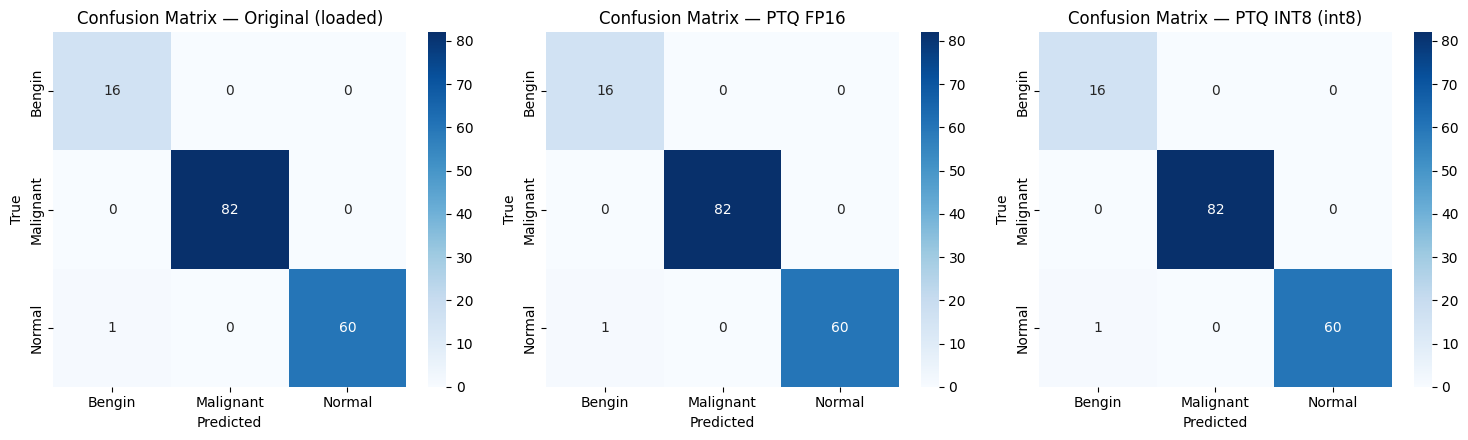

In [11]:
# ============================================================================
# RESOURCE / SIZE / METRIC COMPARISON TABLES
# ============================================================================
size_orig_total = orig_size_cnn + orig_size_svm + orig_size_scaler
size_fp16_kb    = get_file_size_kb(fp16_path)
size_int8_kb    = get_file_size_kb(int8_path)

size_fp16_total = (size_fp16_kb +
                   get_file_size_kb("artifacts/svm_fp16.pkl") +
                   get_file_size_kb("artifacts/scaler_fp16.pkl"))
size_int8_total = (size_int8_kb +
                   get_file_size_kb("artifacts/svm_int8.pkl") +
                   get_file_size_kb("artifacts/scaler_int8.pkl"))

res_df = resource_table([
    ("Original (.keras)",
     size_orig_total, model_orig.count_params(),
     metrics_orig["feat_time"], metrics_orig["inf_time"]),
    ("PTQ FP16 (.tflite)",
     size_fp16_total, model_orig.count_params(),
     metrics_fp16["feat_time"], metrics_fp16["inf_time"]),
    ("PTQ INT8 (.tflite)",
     size_int8_total, model_orig.count_params(),
     metrics_int8["feat_time"], metrics_int8["inf_time"]),
])
print("\n" + "=" * 78)
print("RESOURCE COMPARISON")
print("=" * 78)
print(res_df.to_string(index=False))

size_df = pd.DataFrame([
    ["Feature Extractor",
     orig_size_extractor, size_fp16_kb, size_int8_kb],
    ["SVM Classifier",
     orig_size_svm,
     get_file_size_kb("artifacts/svm_fp16.pkl"),
     get_file_size_kb("artifacts/svm_int8.pkl")],
    ["Feature Scaler",
     orig_size_scaler,
     get_file_size_kb("artifacts/scaler_fp16.pkl"),
     get_file_size_kb("artifacts/scaler_int8.pkl")],
], columns=["Komponen", "Awal (KB)", "FP16 (KB)", "INT8 (KB)"])
size_df.loc[len(size_df)] = ["TOTAL",
                             size_df["Awal (KB)"].sum(),
                             size_df["FP16 (KB)"].sum(),
                             size_df["INT8 (KB)"].sum()]
print("\nFILE-LEVEL SIZE COMPARISON")
print(size_df.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

summary_df = pd.DataFrame({
    "Metric"   : ["Accuracy", "Sensitivity (mean)", "Specificity (mean)",
                  "F1-Score (mean)", "AUC (macro)"],
    "Original" : [
        f'{metrics_orig["accuracy"]:.4f}',
        f'{np.mean(metrics_orig["sensitivity"]):.4f}',
        f'{np.mean(metrics_orig["specificity"]):.4f}',
        f'{np.mean(metrics_orig["f1"          ]):.4f}',
        f'{metrics_orig["auc_macro"]:.4f}',
    ],
    "FP16"     : [
        f'{metrics_fp16["accuracy"]:.4f}',
        f'{np.mean(metrics_fp16["sensitivity"]):.4f}',
        f'{np.mean(metrics_fp16["specificity"]):.4f}',
        f'{np.mean(metrics_fp16["f1"          ]):.4f}',
        f'{metrics_fp16["auc_macro"]:.4f}',
    ],
    "INT8"     : [
        f'{metrics_int8["accuracy"]:.4f}',
        f'{np.mean(metrics_int8["sensitivity"]):.4f}',
        f'{np.mean(metrics_int8["specificity"]):.4f}',
        f'{np.mean(metrics_int8["f1"          ]):.4f}',
        f'{metrics_int8["auc_macro"]:.4f}',
    ],
})
print("\n" + "=" * 78)
print("METRIC SUMMARY (Original vs FP16 vs INT8)")
print("=" * 78)
print(summary_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_confusion_matrix(metrics_orig, class_names, ax=axes[0])
plot_confusion_matrix(metrics_fp16, class_names, ax=axes[1])
plot_confusion_matrix(metrics_int8, class_names, ax=axes[2])
plt.tight_layout(); plt.show()


In [12]:
# ============================================================================
# SAVE QUANTIZED ARTEFACTS TO NEW FOLDER
# ============================================================================
from datetime import datetime
out_folder = f"saved_models_quantization_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(out_folder, exist_ok=True)

shutil.copy2(fp16_path, os.path.join(out_folder, "feature_extractor_fp16.tflite"))
shutil.copy2(int8_path, os.path.join(out_folder, "feature_extractor_int8.tflite"))
shutil.copy2("artifacts/svm_fp16.pkl"   , os.path.join(out_folder, "svm_classifier_fp16.pkl"))
shutil.copy2("artifacts/scaler_fp16.pkl", os.path.join(out_folder, "feature_scaler_fp16.pkl"))
shutil.copy2("artifacts/svm_int8.pkl"   , os.path.join(out_folder, "svm_classifier_int8.pkl"))
shutil.copy2("artifacts/scaler_int8.pkl", os.path.join(out_folder, "feature_scaler_int8.pkl"))

with open(os.path.join(out_folder, "model_info.txt"), "w") as f:
    f.write("Post-Training Quantization (PTQ)\n")
    f.write(f"Original test accuracy : {metrics_orig['accuracy']:.4f}\n")
    f.write(f"FP16     test accuracy : {metrics_fp16['accuracy']:.4f}\n")
    f.write(f"INT8     test accuracy : {metrics_int8['accuracy']:.4f}\n")

print(f"Quantized artefacts saved to {out_folder}/")
for fn in sorted(os.listdir(out_folder)):
    fp = os.path.join(out_folder, fn)
    print(f"  {fn:<40} {get_file_size_kb(fp):>10.2f} KB")


Quantized artefacts saved to saved_models_quantization_20260428_133736/
  feature_extractor_fp16.tflite               6361.28 KB
  feature_extractor_int8.tflite               3188.63 KB
  feature_scaler_fp16.pkl                        0.98 KB
  feature_scaler_int8.pkl                        0.98 KB
  model_info.txt                                 0.13 KB
  svm_classifier_fp16.pkl                        9.39 KB
  svm_classifier_int8.pkl                        9.22 KB
